### EDA Summary

- Arrival delays are right-skewed with extreme outliers
- Dataset is class-imbalanced (delayed vs on-time)
- Cancellation and diversion records must be removed
- Delay breakdown columns cause data leakage and must not be used
- Airline and origin airport significantly affect delay probability
- Airport geographic metadata can be successfully joined
- Weather integration using airport location and date is feasible


### Imports & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

# ── Update these paths to match your data location ──
FLIGHTS_PATH  = "data/raw/flight_data.csv"
AIRPORTS_PATH = "data/raw/airports.csv"

flights  = pd.read_csv(FLIGHTS_PATH)
airports = pd.read_csv(AIRPORTS_PATH)

print("Flights shape :", flights.shape)
print("Airports shape:", airports.shape)


Flights shape : (539747, 34)
Airports shape: (9300, 17)


### Basic Sanity Checks

In [8]:
flights.head()


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_TIME_BLK,TAXI_OUT,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DIV_ACTUAL_ELAPSED_TIME
0,2025,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",500,452.0,-8.0,0.0,0001-0559,16.0,10.0,754,733.0,0.0,0700-0759,0.0,NaN,0.0,75.0,569.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",555,552.0,-3.0,0.0,0001-0559,13.0,13.0,849,832.0,0.0,0800-0859,0.0,NaN,0.0,74.0,569.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",820,815.0,-5.0,0.0,0800-0859,13.0,11.0,1114,1052.0,0.0,1100-1159,0.0,NaN,0.0,73.0,569.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",1032,1029.0,-3.0,0.0,1000-1059,12.0,5.0,1323,1300.0,0.0,1300-1359,0.0,NaN,0.0,74.0,569.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",1700,1707.0,7.0,7.0,1700-1759,20.0,19.0,1948,2005.0,17.0,1900-1959,0.0,NaN,0.0,79.0,569.0,7.0,0.0,10.0,0.0,0.0,NaN


In [9]:
airports.head()


,icao_code,iata_code,name,city,country,lat_deg,lat_min,lat_sec,lat_dir,lon_deg,lon_min,lon_sec,lon_dir,altitude,lat_decimal,lon_decimal,id
0,AYGA,GKA,GOROKA,GOROKA,PAPUA NEW GUINEA,6,4,54,S,145,23,30,E,1610,-6.082,145.392,1
1,AYLA,LAE,NaN,LAE,PAPUA NEW GUINEA,0,0,0,U,0,0,0,U,0,0.000,0.000,2
2,AYMD,MAG,MADANG,MADANG,PAPUA NEW GUINEA,5,12,25,S,145,47,19,E,7,-5.207,145.789,3
3,AYMH,HGU,MOUNT HAGEN,MOUNT HAGEN,PAPUA NEW GUINEA,5,49,34,S,144,17,46,E,1643,-5.826,144.296,4
4,AYNZ,LAE,NADZAB,NADZAB,PAPUA NEW GUINEA,6,34,11,S,146,43,34,E,73,-6.570,146.726,5


### Column Overview

In [10]:
flights.info()


<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   YEAR                     539747 non-null  int64  
 1   MONTH                    539747 non-null  int64  
 2   DAY_OF_MONTH             539747 non-null  int64  
 3   DAY_OF_WEEK              539747 non-null  int64  
 4   FL_DATE                  539747 non-null  str    
 5   OP_UNIQUE_CARRIER        539747 non-null  str    
 6   OP_CARRIER_AIRLINE_ID    539747 non-null  int64  
 7   OP_CARRIER               539747 non-null  str    
 8   ORIGIN                   539747 non-null  str    
 9   ORIGIN_CITY_NAME         539747 non-null  str    
 10  DEST                     539747 non-null  str    
 11  DEST_CITY_NAME           539747 non-null  str    
 12  CRS_DEP_TIME             539747 non-null  int64  
 13  DEP_TIME                 523861 non-null  float64
 14  DEP_DELAY      

In [11]:
airports.info()


<class 'pandas.DataFrame'>
RangeIndex: 9300 entries, 0 to 9299
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   icao_code    9300 non-null   str    
 1   iata_code    3562 non-null   str    
 2   name         4195 non-null   str    
 3   city         9300 non-null   str    
 4   country      9300 non-null   str    
 5   lat_deg      9300 non-null   int64  
 6   lat_min      9300 non-null   int64  
 7   lat_sec      9300 non-null   int64  
 8   lat_dir      9300 non-null   str    
 9   lon_deg      9300 non-null   int64  
 10  lon_min      9300 non-null   int64  
 11  lon_sec      9300 non-null   int64  
 12  lon_dir      9300 non-null   str    
 13  altitude     9300 non-null   int64  
 14  lat_decimal  9300 non-null   float64
 15  lon_decimal  9300 non-null   float64
 16  id           9300 non-null   int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 1.5 MB


### Missing Value Analysis (Flights)

In [12]:
missing_flights = flights.isnull().mean().sort_values(ascending=False)
missing_flights[missing_flights > 0]


DIV_ACTUAL_ELAPSED_TIME    0.998336
CANCELLATION_CODE          0.969778
LATE_AIRCRAFT_DELAY        0.818193
SECURITY_DELAY             0.818193
NAS_DELAY                  0.818193
WEATHER_DELAY              0.818193
CARRIER_DELAY              0.818193
AIR_TIME                   0.032382
ARR_DELAY_NEW              0.032382
TAXI_IN                    0.030718
ARR_TIME                   0.030718
TAXI_OUT                   0.030064
DEP_DELAY                  0.029501
DEP_DELAY_NEW              0.029501
DEP_TIME                   0.029432
dtype: float64

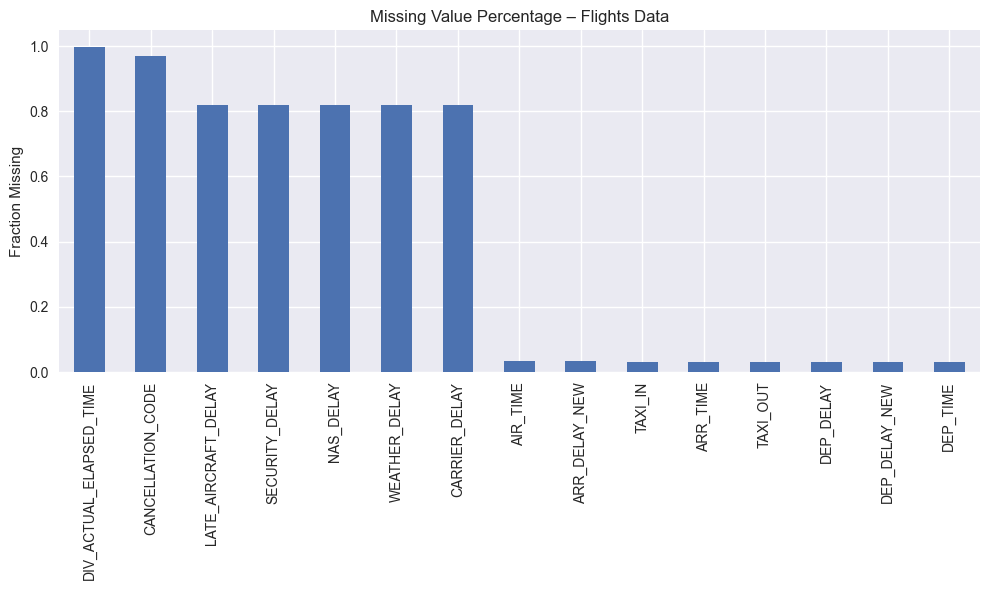

In [13]:
plt.figure(figsize=(10, 6))
missing_flights[missing_flights > 0].plot(kind="bar")
plt.title("Missing Value Percentage – Flights Data")
plt.ylabel("Fraction Missing")
plt.tight_layout()
plt.show()


### Missing Value Analysis (Airports)

In [14]:
airports.isnull().sum()


icao_code         0
iata_code      5738
name           5105
city              0
country           0
lat_deg           0
lat_min           0
lat_sec           0
lat_dir           0
lon_deg           0
lon_min           0
lon_sec           0
lon_dir           0
altitude          0
lat_decimal       0
lon_decimal       0
id                0
dtype: int64

### Date & Time Understanding

In [15]:
flights[["FL_DATE", "YEAR", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK"]].head()


,FL_DATE,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK
0,1/1/2025 12:00:00 AM,2025,1,1,3
1,1/1/2025 12:00:00 AM,2025,1,1,3
2,1/1/2025 12:00:00 AM,2025,1,1,3
3,1/1/2025 12:00:00 AM,2025,1,1,3
4,1/1/2025 12:00:00 AM,2025,1,1,3


In [16]:
# Check date consistency
pd.to_datetime(flights["FL_DATE"]).dt.year.value_counts().sort_index()


/var/folders/0k/lbvs8t7s1rx9_rsngx67x2z00000gn/T/ipykernel_26505/3412994757.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(flights["FL_DATE"]).dt.year.value_counts().sort_index()


FL_DATE
2025    539747
Name: count, dtype: int64

### Target Variable Exploration (Arrival Delay)

NOTE: We define DELAYED here only for EDA purposes — NOT on the raw DataFrame that feeds into training.
The official target is created in feature_engineering.ipynb after cleaning.

DELAYED
0    0.824318
1    0.175682
Name: proportion, dtype: float64


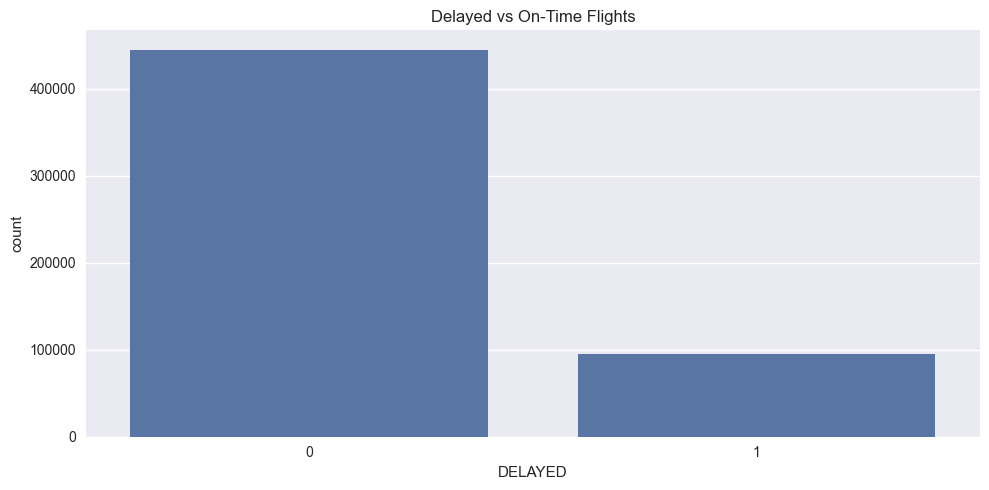

In [17]:
# Work on a copy so we don't pollute the raw flights DataFrame
flights_eda = flights.copy()
flights_eda["DELAYED"] = (flights_eda["ARR_DELAY_NEW"] > 15).astype(int)

print(flights_eda["DELAYED"].value_counts(normalize=True))

sns.countplot(x="DELAYED", data=flights_eda)
plt.title("Delayed vs On-Time Flights")
plt.tight_layout()
plt.show()


### Distribution of Delay Minutes

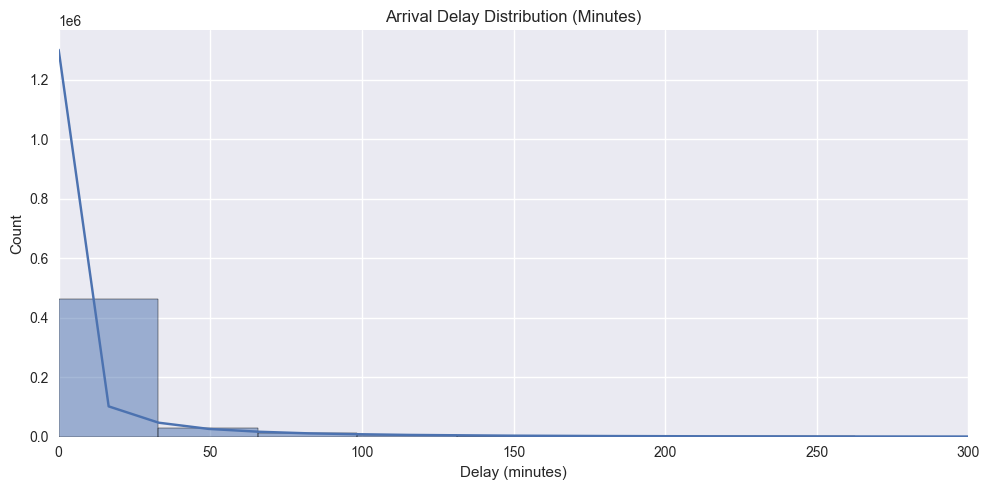

In [18]:
sns.histplot(flights_eda["ARR_DELAY_NEW"].dropna(), bins=100, kde=True)
plt.xlim(0, 300)
plt.title("Arrival Delay Distribution (Minutes)")
plt.xlabel("Delay (minutes)")
plt.tight_layout()
plt.show()


### Cancellations & Diversions

In [19]:
print("Cancellation rate:")
print(flights["CANCELLED"].value_counts(normalize=True))
print("\nDiversion rate:")
print(flights["DIVERTED"].value_counts(normalize=True))


Cancellation rate:
CANCELLED
0.0    0.969778
1.0    0.030222
Name: proportion, dtype: float64

Diversion rate:
DIVERTED
0.0    0.99784
1.0    0.00216
Name: proportion, dtype: float64


### Airline-Level Delay Patterns

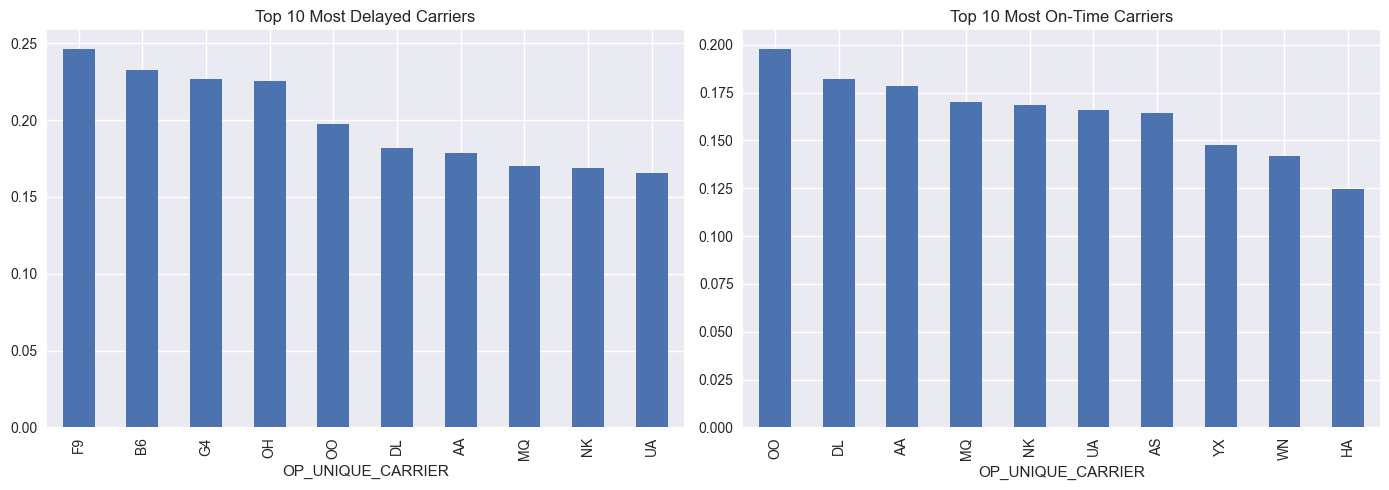

In [20]:
carrier_delay = (
    flights_eda.groupby("OP_UNIQUE_CARRIER")["DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
carrier_delay.head(10).plot(kind="bar", ax=axes[0], title="Top 10 Most Delayed Carriers")
carrier_delay.tail(10).plot(kind="bar", ax=axes[1], title="Top 10 Most On-Time Carriers")
plt.tight_layout()
plt.show()


### Origin Airport Delay Patterns

In [21]:
origin_delay = (
    flights_eda.groupby("ORIGIN")["DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 most delayed origin airports:")
print(origin_delay.head(10))


Top 10 most delayed origin airports:
ORIGIN
CKB    0.777778
SCE    0.562500
TOL    0.451613
SMX    0.444444
COD    0.403226
BRW    0.400000
TVC    0.378676
SUX    0.370968
PRC    0.370968
USA    0.360000
Name: DELAYED, dtype: float64


### Joining Airport Metadata (Preview Only)

In [22]:
flights_airport_preview = flights.merge(
    airports[["iata_code", "lat_decimal", "lon_decimal", "altitude"]],
    left_on="ORIGIN",
    right_on="iata_code",
    how="left"
)

flights_airport_preview[["ORIGIN", "lat_decimal", "lon_decimal", "altitude"]].head()


,ORIGIN,lat_decimal,lon_decimal,altitude
0,ABQ,0.00,0.000,0.0
1,ABQ,35.04,-106.609,1633.0
2,ABQ,0.00,0.000,0.0
3,ABQ,35.04,-106.609,1633.0
4,ABQ,0.00,0.000,0.0


### Correlation (Numeric Features)

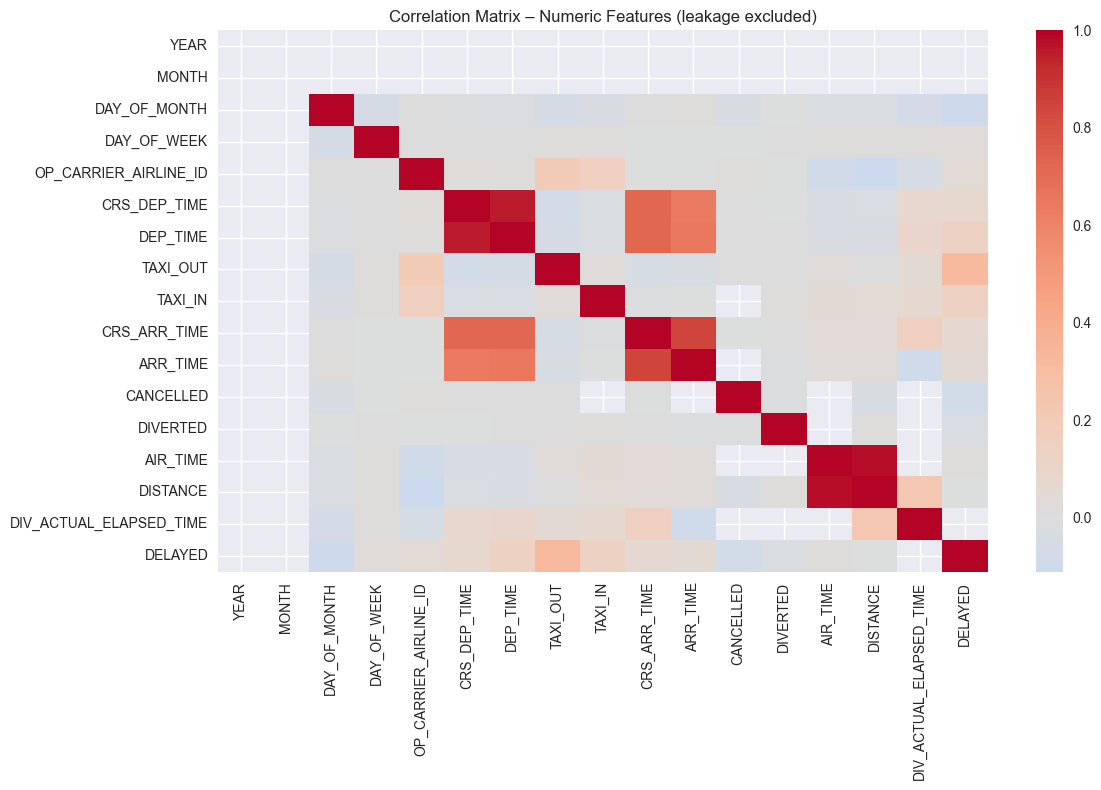

In [23]:
# Exclude known leakage columns before computing correlation
leakage_cols = [
    "ARR_DELAY_NEW", "DEP_DELAY", "DEP_DELAY_NEW",
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
    "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"
]
numeric_cols = (
    flights_eda
    .drop(columns=[c for c in leakage_cols if c in flights_eda.columns])
    .select_dtypes(include=np.number)
)

corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix – Numeric Features (leakage excluded)")
plt.tight_layout()
plt.show()
